# Analyse — `marl-rllib-gpu-bench`

Lit tous les `logs/*.jsonl` (un fichier par `run_id`+config), et compare les
5 configs A-E : débit (échantillons/s), trajectoire par itération, mémoire
GPU, et une comparaison avec les chiffres déjà mesurés sur Jetson
(`SOTA_MARL_RLlib/docs/jetson_gpu_optim.md`).

Ce notebook ne recalcule rien depuis les configs — il lit uniquement ce que
`bench/run_bench.py` a écrit.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

LOGS_DIR = Path("../logs")

log_files = sorted(LOGS_DIR.glob("*.jsonl"))
print(f"{len(log_files)} fichier(s) log trouvé(s) dans {LOGS_DIR.resolve()}")
for f in log_files:
    print(" ", f.name)

1 fichier(s) log trouvé(s) dans /home/bnj/marl-rllib-gpu-bench/logs
  example_smoke_test_local_cpu.jsonl


In [2]:
rows = []
for f in log_files:
    with open(f) as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))

if not rows:
    print(
        "Aucune ligne trouvée. Lance d'abord :\n"
        "  uv run python -m bench.run_bench --configs A,B,C,D,E --iters 5\n"
        "(ou --configs A --iters 2 --force-cpu pour un smoke-test sans GPU)"
    )

df = pd.DataFrame(rows)
print(df.shape, "lignes x colonnes")
df[[c for c in df.columns if c.startswith("bench_config/") or c in
    ("iter", "is_warmup", "wall_time_s", "throughput_sps")]].head(10)

(3, 329) lignes x colonnes


,iter,is_warmup,wall_time_s,throughput_sps,bench_config/name,bench_config/label,bench_config/batch,bench_config/minibatch,bench_config/workers,bench_config/use_gpu,bench_config/num_learners,bench_config/hiddens
0,0,True,5.435982,376.748832,A,référence CPU,2048,256,1,False,0,None
1,1,False,4.872022,420.359358,A,référence CPU,2048,256,1,False,0,None
2,2,False,4.493252,455.794611,A,référence CPU,2048,256,1,False,0,None


## Débit moyen par config (hors warmup)

,mean,std,count
config_name,,,
A — référence CPU,438.076985,25.056507,2


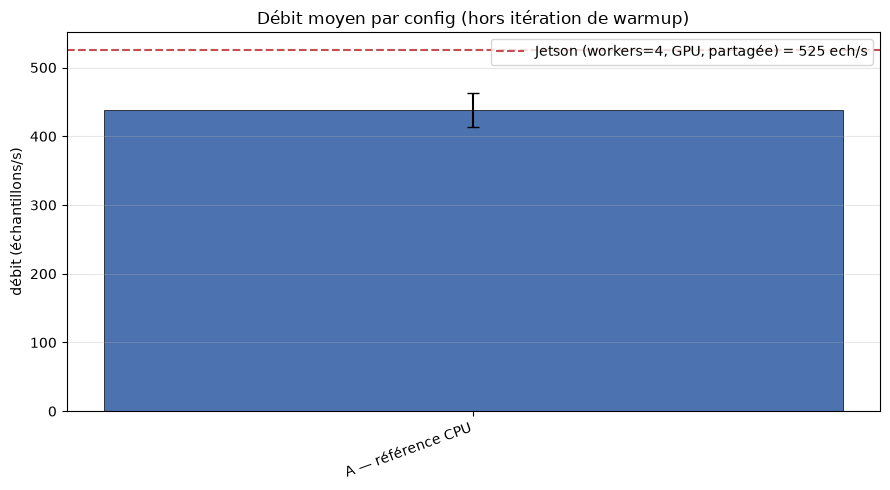

In [3]:
JETSON_REFERENCE_SPS = 525  # workers=4, GPU, policy partagée — jetson_gpu_optim.md (SOTA_MARL_RLlib)

if not df.empty:
    steady = df[~df["is_warmup"]].copy()
    steady["config_name"] = steady["bench_config/name"] + " — " + steady["bench_config/label"]

    agg = (
        steady.groupby("config_name")["throughput_sps"]
        .agg(["mean", "std", "count"])
        .sort_index()
    )
    display(agg)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(agg.index, agg["mean"], yerr=agg["std"].fillna(0), capsize=4,
           color="#4C72B0", edgecolor="black", linewidth=0.5)
    ax.axhline(JETSON_REFERENCE_SPS, color="#C44E52", linestyle="--", linewidth=1.5,
               label=f"Jetson (workers=4, GPU, partagée) = {JETSON_REFERENCE_SPS} ech/s")
    ax.set_ylabel("débit (échantillons/s)")
    ax.set_title("Débit moyen par config (hors itération de warmup)")
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

## Temps par itération (warmup visible)

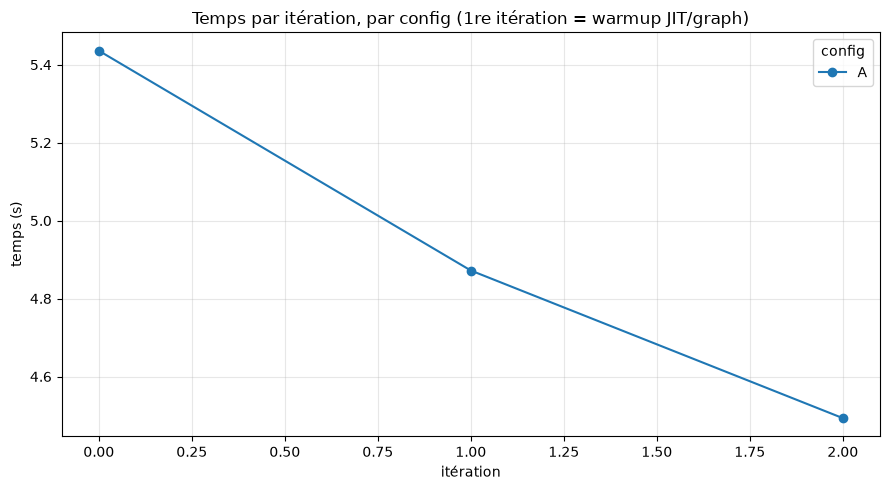

In [4]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    for name, group in df.groupby("bench_config/name"):
        group = group.sort_values("iter")
        ax.plot(group["iter"], group["wall_time_s"], marker="o", label=name)
    ax.set_xlabel("itération")
    ax.set_ylabel("temps (s)")
    ax.set_title("Temps par itération, par config (1re itération = warmup JIT/graph)")
    ax.legend(title="config")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

## Mémoire GPU (si disponible)

In [5]:
if not df.empty and df["gpu_mem_allocated_mb"].notna().any():
    gpu_df = df[df["gpu_mem_allocated_mb"].notna()]
    fig, ax = plt.subplots(figsize=(9, 5))
    for name, group in gpu_df.groupby("bench_config/name"):
        group = group.sort_values("iter")
        ax.plot(group["iter"], group["gpu_mem_allocated_mb"], marker="o", label=name)
    ax.set_xlabel("itération")
    ax.set_ylabel("mémoire GPU allouée (Mo)")
    ax.set_title("Mémoire GPU allouée par itération, par config")
    ax.legend(title="config")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("Pas de mesure GPU dans les logs chargés (aucune config GPU exécutée pour l'instant).")

Pas de mesure GPU dans les logs chargés (aucune config GPU exécutée pour l'instant).


## Table récap

In [6]:
if not df.empty:
    cols = ["bench_config/name", "bench_config/label", "bench_config/batch",
            "bench_config/minibatch", "bench_config/workers", "bench_config/use_gpu",
            "bench_config/num_learners", "bench_config/hiddens"]
    recap = (
        steady.groupby(cols, dropna=False)["throughput_sps"]
        .mean()
        .reset_index()
        .rename(columns={c: c.replace("bench_config/", "") for c in cols} | {"throughput_sps": "débit moyen (ech/s)"})
        .sort_values("name")
    )
    display(recap)

,name,label,batch,minibatch,workers,use_gpu,num_learners,hiddens,débit moyen (ech/s)
0,A,référence CPU,2048,256,1,False,0,NaN,438.076985
